# WEC Farm Simulation
In this section we bout to demonstrate how to setup the required objects to run our WEC Farm Simulation.


## Objects and Responsibilities

* ### WaveField (Site) 
    Provides the sea-state distribution over **wave height (H)**, **period (T)**, and **direction (D)**. The site returns either:  
      * **probabilities** `P(H,T,D)` that sum to **1.0** per device (`kind='prob'`)  

      * **hours** `Hours(H,T,D)` that sum to **8760** per device (`kind='hours'`)

<br>

* ### OSWECDevice (Device)  
    Supplies **peak power** on the `(H,T,D)` grid via a surrogate trained on WEC‑Sim: `Power_kW(H,T,D)` (kW). 

    NOTE: A scalar **alpha** maps peak to mean power is being used, it is a temporary feature that must be changed when a new model is implemented:
    `MeanPower_kW(H,T,D) ≈ alpha × Power_kW(H,T,D)`.

<br>

* ### WecFarm (Farm)  
    Binds the site and device to compute **AEP per device** and **total farm AEP**.


### WaveField (`site`) 
The `site` offers a concise description of a location’s wave climate, enhanced by `xrarray`. It provides the probabilities of wave `height (H)`, `period (T)`, and `direction (D)`, and optionally illustrates how these parameters vary across space `(x, y)` for grid spatial distribution analysis. You may select device locations to retrieve the specific combination of `H`, `T`, and `D` that they will experience. From the site, you can access sea state distributions for each device, available as probabilities or hours per year. Furthermore, it features direction roses for the entire area or specific devices, as well as expected maps such as the average wave height `E[H](x, y)` and period `E[T](x, y)`. This resource serves as a crucial backbone for wave climate data, supporting power estimation, layout optimization, and effective visualization.

`Site (XR-backed WaveField)`
* A compact container of a location’s wave climate over H, T, D (and optionally x, y) that you can query and summarize.
  
* Key methods: `local_seastate(x,y)` gets the local H–T–D distribution; `direction_distribution(...)` gives a wave-rose; `expected_map('H'|'T')` gives average height/period.

<br>

`UniformWaveField`
* A non-spatial site: one fixed H–T–D probability table applies everywhere.
  
* Methods: constructor from bin edges (optionally with `pdf`), `from_constant(H,T,D)`, and `from_scatter_and_rose(H_edges,T_edges,D_edges,P_HT,P_D)`.

<br>

`RandomGridWaveField`
* A spatial site: a full probability cube $P(H,T,D,x,y)$ at each grid cell, with optional smoothing for realism.
  
* Methods: constructor from edges and grid (optionally with `grid_P`), and `from_scatter_and_rose_maps(...)` to build per-cell climatology.
  
<br>
<b>Note:</b> a loader class will be added to read real sea-state files and produce sites in the exact format used by these simulations.

---

### Usage Example

Begin with setting up site, here we defining three different sites for three different cases.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from waveField import UniformWaveField, RandomGridWaveField


# Define bin edges (H in m, T in s, D in deg)
H_edges = np.linspace(0.5, 4.0, 7)   # 6 H bins
T_edges = np.linspace(5.0, 10.0, 6)  # 5 T bins
D_edges = np.linspace(0.0, 360.0, 13)  # 12 D bins (full compass)


# Bin edges
H_edges = np.linspace(0.5, 4.0, 7)
T_edges = np.linspace(5.0, 10.0, 6)
D_edges = np.linspace(0.0, 360.0, 13)

# 1) UniformWaveField WITHOUT pdf (your class handles the edge case)
site_no_pdf = UniformWaveField(H_edges, T_edges, D_edges)

# 2) UniformWaveField WITH pdf
rng = np.random.default_rng(0)
pdf = rng.random((len(H_edges)-1, len(T_edges)-1, len(D_edges)-1))
site_pdf = UniformWaveField(H_edges, T_edges, D_edges, pdf=pdf)

# 3) RandomGridWaveField WITHOUT grid_P (random field, your class normalizes per cell)
xg = np.linspace(0, 1000, 30)
yg = np.linspace(0, 1000, 30)
site_grid = RandomGridWaveField(H_edges, T_edges, D_edges, xg, yg, smooth_sigma=0.5)

Therefore, we will compute the wave condition of the local sea states for the different sites and visualize their probability distribution for H, T, and D.

Uniform (no pdf)
  sum P(H), P(T), P(D): 1.0 1.0 1.0


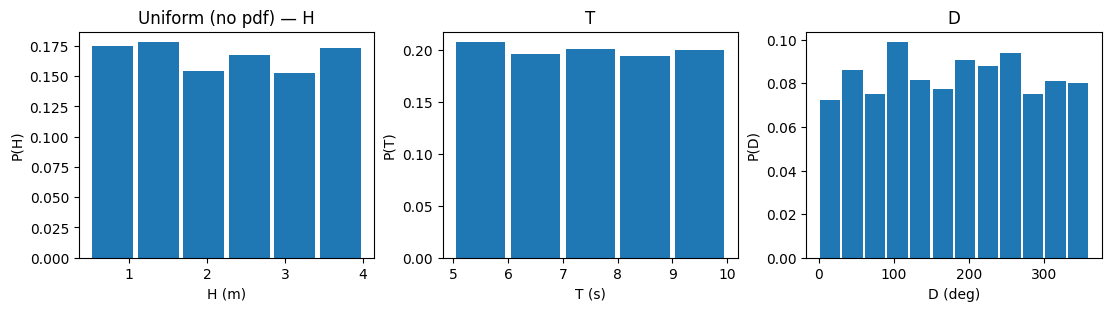

Uniform (with pdf)
  sum P(H), P(T), P(D): 1.0 1.0000000000000002 1.0


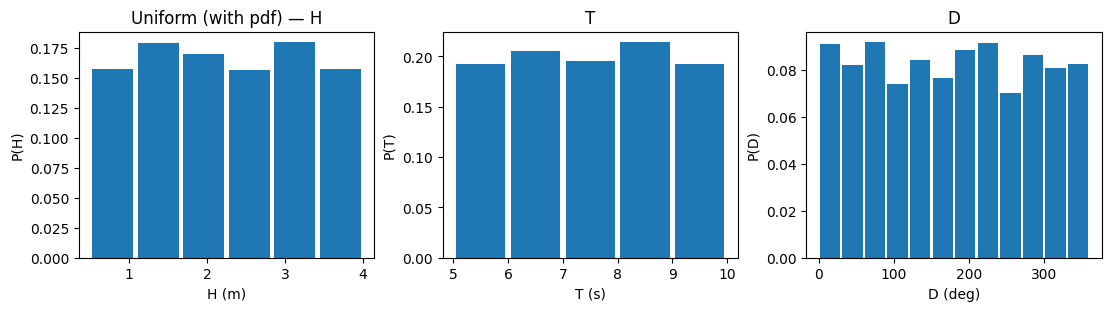

Grid (random, smoothed)
  sum P(H), P(T), P(D): 1.0 1.0 1.0


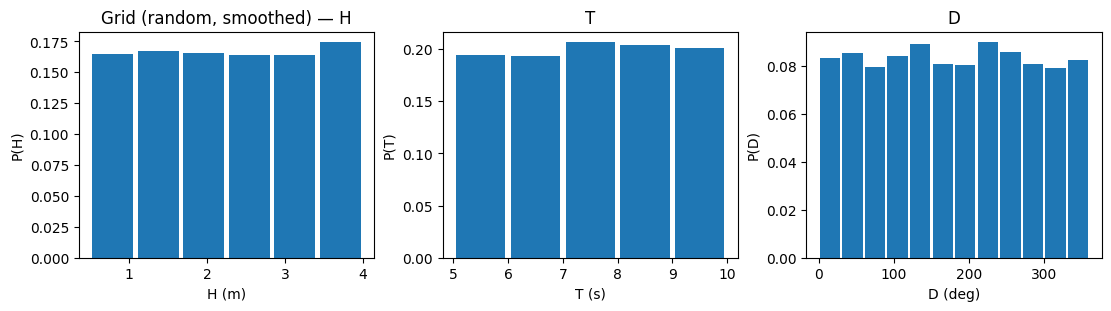

In [ ]:
# For uniform sites, x,y are ignored; for the grid site, pick a point in the grid.
x0, y0 = 500.0, 500.0

# Use stored centers from any Uniform site (same centers across sites with same edges)
Hc = site_no_pdf.ds['H'].values
Tc = site_no_pdf.ds['T'].values
Dc = site_no_pdf.ds['D'].values

sites = [
    ("Uniform (no pdf)", site_no_pdf, 0.0, 0.0),
    ("Uniform (with pdf)", site_pdf, 0.0, 0.0),
    ("Grid (random, smoothed)", site_grid, x0, y0),
]

for name, site, xs, ys in sites:
    P = site.local_seastate([xs], [ys], kind="prob")   # dims: H,T,D,wec
    PH = P.sum(dim=('T','D','wec')).values
    PT = P.sum(dim=('H','D','wec')).values
    PD = P.sum(dim=('H','T','wec')).values

    print(name)
    print("  sum P(H), P(T), P(D):",
          np.sum(PH), np.sum(PT), np.sum(PD))

    fig, ax = plt.subplots(1, 3, figsize=(11, 3), constrained_layout=True)
    ax[0].bar(Hc, PH, width=(Hc[1]-Hc[0])*0.9)
    ax[0].set_xlabel("H (m)"); ax[0].set_ylabel("P(H)"); ax[0].set_title("H")

    ax[1].bar(Tc, PT, width=(Tc[1]-Tc[0])*0.9)
    ax[1].set_xlabel("T (s)"); ax[1].set_ylabel("P(T)"); ax[1].set_title("T")

    ax[2].bar(Dc, PD, width=(Dc[1]-Dc[0])*0.9)
    ax[2].set_xlabel("D (deg)"); ax[2].set_ylabel("P(D)"); ax[2].set_title("D")
    plt.show()